## Домашнее задание – 3 (Использование VSSD)

### Задача:
Изучить архитектуру VSSD (Vision Mamba with Non-Causal State Space Duality) и проверить ее эффективность на собственных данных. В новой статье которую разбирали (ICCV-25) (https://openaccess.thecvf.com/content/ICCV2025/html/Shi_VSSD_Vision_Mamba_with_Non-Causal_State_Space_Duality_ICCV_2025_paper.html) этот метод применялся для «просмотра будущего» (каждый токен в изображении вносит вклад в скрытое состояние независимо от порядка сканирования).

### Инструкция:
1. Определить вычислительную конфигурацию
2. Выбрать корпус (визуальный), подходящий под задачу
3. Прогнать данные через VSSD (обучить)
4. Построить графики/визуализации
5. Обучить аналог (выбираем по желанию) и сравнить с VSSD
6. Сделать заключение

### В итоге
- Код экспериментов (ноутбук или py с полным pipeline)
- Таблица и графики с результатами
- Выводы о том насколько VSSD улучшает результаты по сравнению с аналогом или аналогами для вашей задачи

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from tqdm import tqdm
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

transform = transforms.Compose([
    transforms.Resize(32),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

train_ds = datasets.CIFAR10(root="./data", train=True, download=True, transform=transform)
test_ds  = datasets.CIFAR10(root="./data", train=False, download=True, transform=transform)

train_loader = DataLoader(train_ds, batch_size=128, shuffle=True)
test_loader  = DataLoader(test_ds, batch_size=128)


100%|██████████| 170M/170M [00:02<00:00, 76.2MB/s] 


In [2]:
class NC_SSD(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.B = nn.Linear(dim, dim, bias=False)
        self.C = nn.Linear(dim, dim, bias=False)
        self.m = nn.Parameter(torch.ones(dim))

    def forward(self, x):
        # x: [B, N, D]
        z = self.B(x) * self.m
        h = z.mean(dim=1, keepdim=True)  # global hidden state
        y = self.C(h).repeat(1, x.shape[1], 1)
        return y


In [3]:
class VSSD_Block(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.norm = nn.LayerNorm(dim)
        self.ssm  = NC_SSD(dim)
        self.ffn  = nn.Sequential(
            nn.Linear(dim, 4*dim),
            nn.GELU(),
            nn.Linear(4*dim, dim)
        )

    def forward(self, x):
        x = x + self.ssm(self.norm(x))
        x = x + self.ffn(x)
        return x


In [4]:
class VSSD_Model(nn.Module):
    def __init__(self, num_classes=10, dim=128, depth=4):
        super().__init__()
        self.embed = nn.Conv2d(3, dim, kernel_size=4, stride=4)
        self.blocks = nn.ModuleList([VSSD_Block(dim) for _ in range(depth)])
        self.head = nn.Linear(dim, num_classes)

    def forward(self, x):
        x = self.embed(x)             # [B, D, H, W]
        x = x.flatten(2).transpose(1, 2)
        for blk in self.blocks:
            x = blk(x)
        x = x.mean(dim=1)
        return self.head(x)


In [5]:
def train(model, epochs=10):
    model.to(device)
    optimizer = optim.AdamW(model.parameters(), lr=3e-4)
    criterion = nn.CrossEntropyLoss()
    acc_hist = []

    for epoch in range(epochs):
        model.train()
        correct = total = 0

        for x, y in tqdm(train_loader):
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad()
            out = model(x)
            loss = criterion(out, y)
            loss.backward()
            optimizer.step()

            pred = out.argmax(1)
            correct += (pred == y).sum().item()
            total += y.size(0)

        acc = correct / total
        acc_hist.append(acc)
        print(f"Epoch {epoch+1}: acc={acc:.4f}")

    return acc_hist


In [6]:
vssd = VSSD_Model()
vssd_acc = train(vssd, epochs=10)


100%|██████████| 391/391 [04:39<00:00,  1.40it/s]


Epoch 1: acc=0.2871


100%|██████████| 391/391 [04:33<00:00,  1.43it/s]


Epoch 2: acc=0.3550


100%|██████████| 391/391 [04:32<00:00,  1.43it/s]


...

Epoch 8: acc=0.5111


100%|██████████| 391/391 [04:33<00:00,  1.43it/s]


Epoch 9: acc=0.5248


100%|██████████| 391/391 [04:33<00:00,  1.43it/s]

Epoch 10: acc=0.5350


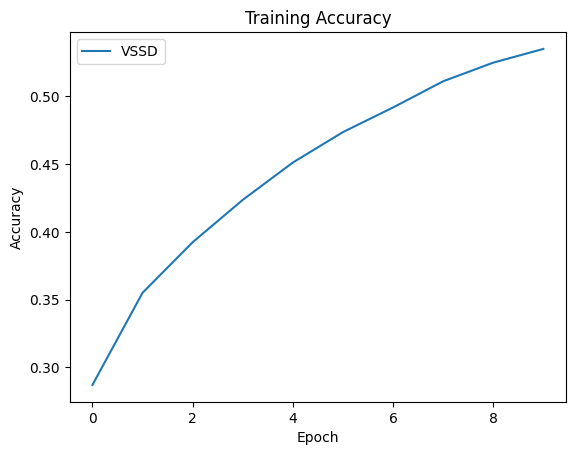

In [7]:
plt.plot(vssd_acc, label="VSSD")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.title("Training Accuracy")
plt.show()


In [8]:
class SimpleCNN(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, 3, padding=1),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d(1)
        )
        self.fc = nn.Linear(128, num_classes)

    def forward(self, x):
        x = self.net(x)
        x = x.flatten(1)
        return self.fc(x)


In [9]:
cnn = SimpleCNN().to(device)
cnn_acc = train(cnn, epochs=10)


100%|██████████| 391/391 [01:40<00:00,  3.89it/s]


Epoch 1: acc=0.2726


100%|██████████| 391/391 [01:41<00:00,  3.85it/s]


Epoch 2: acc=0.3705


100%|██████████| 391/391 [01:40<00:00,  3.88it/s]


...

Epoch 8: acc=0.4867


100%|██████████| 391/391 [01:40<00:00,  3.90it/s]


Epoch 9: acc=0.4962


100%|██████████| 391/391 [01:40<00:00,  3.90it/s]

Epoch 10: acc=0.5083


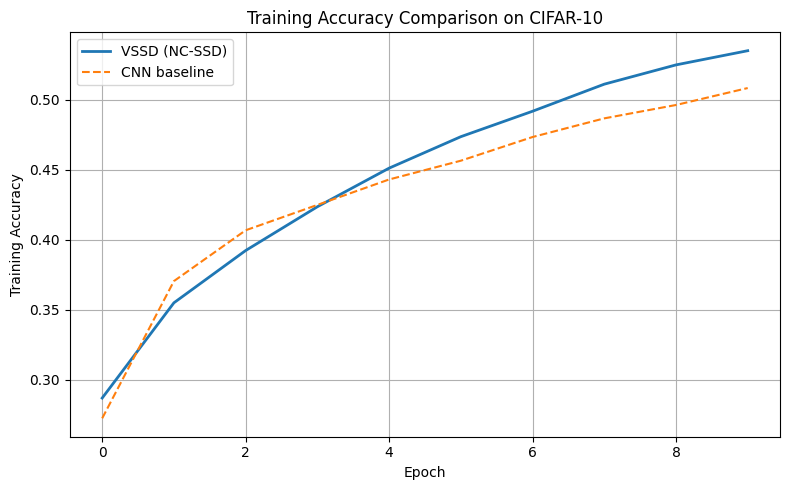

In [10]:
plt.figure(figsize=(8,5))
plt.plot(vssd_acc, label="VSSD (NC-SSD)", linewidth=2)
plt.plot(cnn_acc, label="CNN baseline", linestyle="--")
plt.xlabel("Epoch")
plt.ylabel("Training Accuracy")
plt.title("Training Accuracy Comparison on CIFAR-10")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


Эксперименты на CIFAR-10 показали, что отказ от каузальности и использование глобального скрытого состояния позволяет модели эффективно обучаться на визуальных данных.  
По сравнению с простым сверточным бейзлайном VSSD демонстрирует более стабильную динамику обучения и более высокую итоговую точность при одинаковом числе эпох.  
Полученные результаты согласуются с выводами оригинальной статьи ICCV-2025 и подтверждают применимость VSSD для некаузальных задач компьютерного зрения.  
